In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 610
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 3.4900e+02  3.8265e+03 -1.3990e+03  3.7120e+03 -3.6900e+02  3.8085e+03
 -7.8100e+02  3.6530e+03 -1.6115e+03  3.7675e+03  4.3550e+02  3.7490e+03
 -2.8025e+03  3.8620e+03  1.7140e+03  3.4975e+03 -3.2370e+03  3.8785e+03
  2.5660e+03  3.4885e+03 -2.9360e+03  3.8120e+03  2.6200e+03  3.5130e+03
 -2.4225e+03  3.7445e+03  2.2160e+03  3.5575e+03 -2.2800e+03  3.7500e+03
  1.9065e+03  3.6030e+03  9.5900e+02  3.6395e+03 -1.6105e+03  3.7825e+03
  1.2225e+03  3.5925e+03 -2.1965e+03  3.7770e+03  5.2500e+02  3.7915e+03
 -1.6330e+03  3.7250e+03 -6.0200e+02  3.7855e+03 -4.1500e+02  3.7740e+03
 -1.7700e+03  3.8420e+03  8.0700e+02  3.6225e+03 -2.2155e+03  3.8375e+03
  1.6300e+03  3.5360e+03 -2.0300e+03  3.7690e+03  1.8360e+03  3.5445e+03
 -1.7095e+03  3.7030e+03  1.6790e+03  3.5700e+03  1.0275e+03  3.5875e+03
 -1.1395e+03  3.7320e+03  2.1480e+03  3.5045e+03 -2.5835e+03  3.8030e+03
  2.2845e+03  3.5150e+03 -3.1410e+03  3.8350e+03  1.4360e+03  3.6010e+03
 -2.6170e+03  3.793

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

3 µs ± 168 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/625-50_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.0  # Fixed ideal EM gain

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': -0.1563050290339198, 'epsilon': 0.4438508451811046, 'theta': -40.483260805422816}, 'flc': {'phi': 3.088832086894012, 'delta_theta': 1.1665130300148232}, 'optics': {'phi': -0.7500142397393497, 'epsilon': 0.04797599186476884, 'theta': 18.546605166124095}, 'image_rotator': {'phi': 1.503079227354812}, 'hwp': {'phi': 2.757112220789998, 'delta_theta': 2.1341629513243436}, 'lp': {'theta': 5.0}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.49637475 0.4888337  0.08619457 0.        ]
 [0.49637475 0.4888337  0.08619457 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -0.1563050290339198, 'epsilon': 0.4438508451811046, 'theta': -40.483260805422816}, 'flc': {'phi': 3.088832086894012, 'delta_theta': 1.1665130300148232}, 'optics': {'phi': -0.7500142397393497, 'epsilon': 0.04797599186476884, 'theta': 18.546605166124095}, 'image_rotator': {'phi': 1.503079227354812}, 'hwp': {'phi': 2.757112220789998, 'delta_theta': 2.1341629513243436}, 'lp': {'theta': 5.0}}
logl value: 19977.90879360473


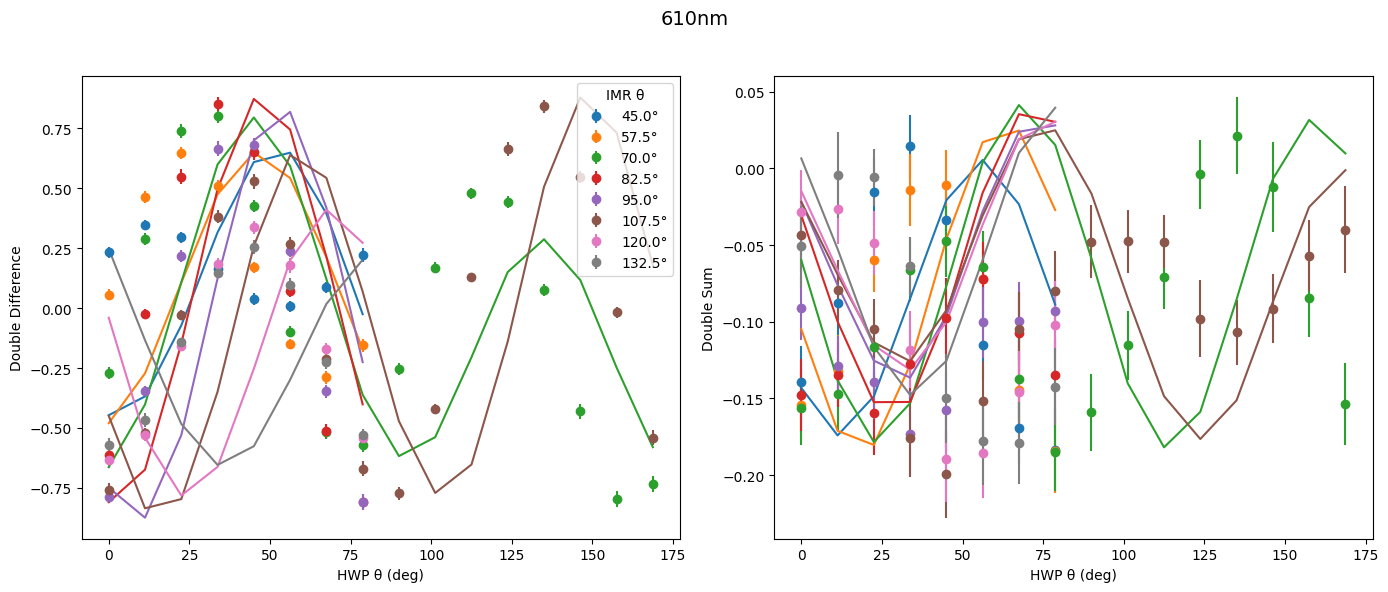

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

In [ ]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 0.1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),
    },
    "hwp": {
        "phi": (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

In [ ]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)